# Untrained random policy

Joint angles → small neural network → 18 bounded offsets. Random weights stay fixed; action noise changes each step. No learning yet.

[Earlier coordinated visual aid](https://github.com/haidmoham/spider/blob/d6238be2bbedf224322e07539e45c68a49525830/lab/notebooks/03_coordinated_baseline.ipynb).

In [1]:
from pathlib import Path
import sys
REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / "spider" / "learning.py").is_file())
sys.path.insert(0, str(REPO_ROOT))
import mujoco
import numpy as np
import pandas as pd
from spider.learning import LearningSimulation, record_policy, plot_recordings
from spider.simulation import neutral_targets
sim = LearningSimulation()
print("Actuator order:", [sim.model.actuator(i).name for i in range(sim.model.nu)])
print("Timestep:", sim.model.opt.timestep, "s")

Actuator order: ['front_left_coxa_motor', 'front_left_hip_motor', 'front_left_knee_motor', 'front_right_coxa_motor', 'front_right_hip_motor', 'front_right_knee_motor', 'middle_left_coxa_motor', 'middle_left_hip_motor', 'middle_left_knee_motor', 'middle_right_coxa_motor', 'middle_right_hip_motor', 'middle_right_knee_motor', 'rear_left_coxa_motor', 'rear_left_hip_motor', 'rear_left_knee_motor', 'rear_right_coxa_motor', 'rear_right_hip_motor', 'rear_right_knee_motor']
Timestep: 0.002 s


In [2]:
import numpy as np

def make_random_policy(weight_seed=7, action_seed=11):
    weight_rng = np.random.default_rng(weight_seed)
    action_rng = np.random.default_rng(action_seed)

    # 18 inputs → 32 hidden units → 18 outputs. Initialize once.
    w1 = weight_rng.normal(0.0, 1.0 / np.sqrt(18), size=(18, 32))
    b1 = np.zeros(32)
    w2 = weight_rng.normal(0.0, 0.01 / np.sqrt(32), size=(32, 18))
    b2 = np.zeros(18)

    max_offset_rad = 0.05  # ±2.9 degrees from neutral.
    exploration_std = 0.20  # Noise before tanh.

    def random_policy(observation):
        x = np.asarray(observation.joint_positions, dtype=float) / 1.0
        hidden = np.tanh(x @ w1 + b1)
        mean = hidden @ w2 + b2

        # Fresh noise each call; tanh bounds the final offsets.
        noise = action_rng.normal(0.0, exploration_std, size=18)
        offsets = max_offset_rad * np.tanh(mean + noise)
        return offsets

    return random_policy

random_policy = make_random_policy()

Recorded 2.00 seconds; 100 actions.


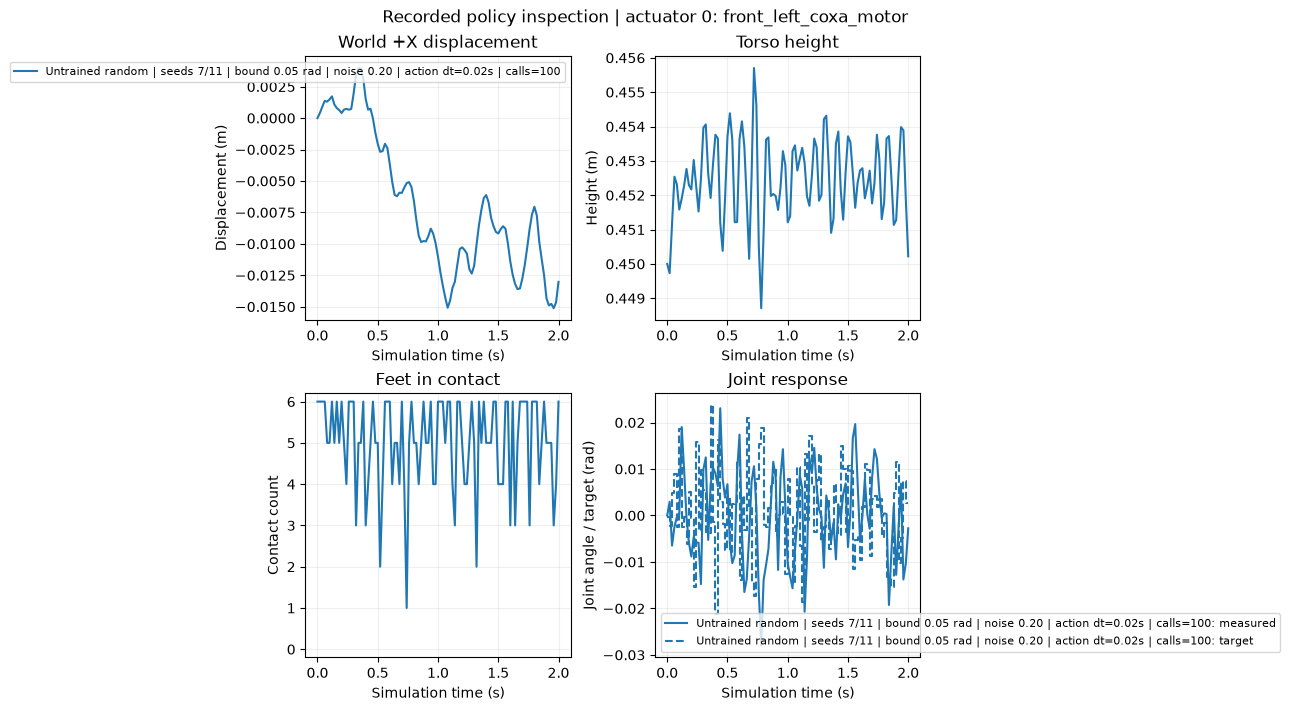

In [3]:
random_recording = record_policy(
    make_random_policy(weight_seed=7, action_seed=11),
    label="Untrained random | seeds 7/11 | bound 0.05 rad | noise 0.20",
    action_count=100, physics_steps=10,
)
times = np.asarray(random_recording.replay.times)
expected = np.arange(101) * 10 * random_recording.replay.model.opt.timestep
assert np.allclose(times, expected, rtol=0, atol=1e-9), "Simulation clock reset: inspect invalid trial."
assert np.isfinite(random_recording.replay.states).all()
print(f"Recorded {times[-1]:.2f} seconds; {len(random_recording.offsets)} actions.")
fig, axes = plot_recordings(random_recording, actuator=0)

In [4]:
# Uncomment when you want to inspect the recorded simulation.
# viewer = random_recording.watch(REPO_ROOT / "telemetry" / "random-policy-replay", speed=1.0)


(<Figure size 1200x700 with 4 Axes>,
 array([[<Axes: title={'center': 'World +X displacement'}, xlabel='Simulation time (s)', ylabel='Displacement (m)'>,
         <Axes: title={'center': 'Torso height'}, xlabel='Simulation time (s)', ylabel='Height (m)'>],
        [<Axes: title={'center': 'Feet in contact'}, xlabel='Simulation time (s)', ylabel='Contact count'>,
         <Axes: title={'center': 'Joint response'}, xlabel='Simulation time (s)', ylabel='Joint angle / target (rad)'>]],
       dtype=object))

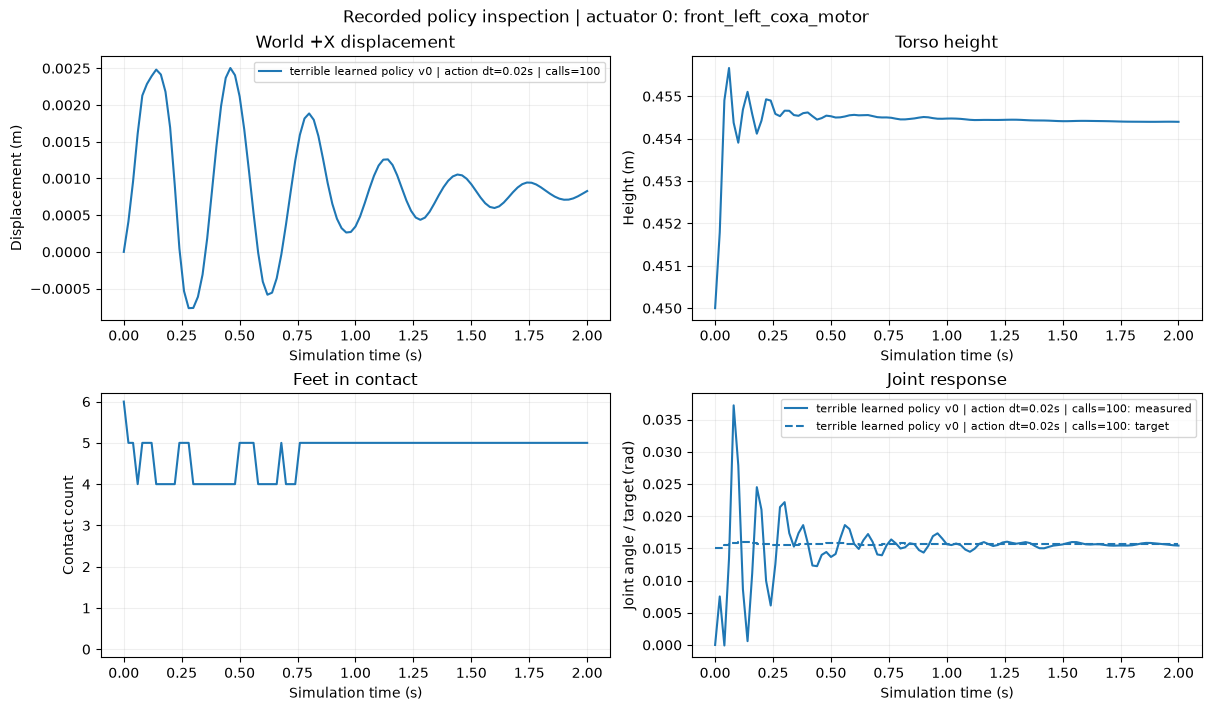

In [5]:
# Reinforcement learning
# terrible first pass — make this real later

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)

OBS_DIM = 18   # wrong? probably. fix me.
ACT_DIM = 18

policy = nn.Sequential(
    nn.Linear(OBS_DIM, 64),
    nn.Tanh(),
    nn.Linear(64, ACT_DIM),
    nn.Tanh(),
)

optimizer = optim.Adam(policy.parameters(), lr=3e-4)

def observation_from(state):
    # START EDITING HERE:
    # decide what the robot should actually be allowed to observe
    observed = state.joint_positions
    measured = state.joint_positions
    return torch.tensor(measured, dtype=torch.float32)

def reward_from(state):
    # START EDITING HERE:
    # this reward is intentionally stupid
    forward = state.torso_position[0]
    upright = state.torso_position[2]
    return forward + 0.1 * upright

def learned_policy(state):
    obs = observation_from(state)

    with torch.no_grad():
        action = policy(obs)

    # small offsets so we don't immediately launch the spider into orbit
    return 0.1 * action.numpy()


recording = record_policy(
    learned_policy,
    label="terrible learned policy v0",
    action_count=100,
    physics_steps=10,
)

plot_recordings(recording)

In [6]:
episode_reward = sum(
    reward_from(state)
    for state in recording.measurements
)

episode_reward

4.67768279317423

In [7]:
rows = []

for state in recording.measurements:
    forward = state.torso_position[0]
    upright = state.torso_position[2]
    reward = reward_from(state)

    rows.append((state.time, forward, upright, reward))

rows[:10]

[(0.0, 0.0, 0.45, 0.045000000000000005),
 (0.020000000000000004,
  0.00041372437228805723,
  0.4517875989018312,
  0.04559248426247118),
 (0.04000000000000002,
  0.0009583554791609016,
  0.4549042813781006,
  0.04644878361697096),
 (0.06000000000000004,
  0.0016108308265274235,
  0.4556665325971113,
  0.04717748408623856),
 (0.08000000000000006,
  0.0021290347939457313,
  0.4543758324016399,
  0.04756661803410973),
 (0.10000000000000007,
  0.0022864392187060935,
  0.4539039715392493,
  0.047676836372631023),
 (0.12000000000000009,
  0.0023922903306485646,
  0.45468481504583386,
  0.04786077183523195),
 (0.1400000000000001,
  0.002482213178215763,
  0.4551044213370969,
  0.04799265531192546),
 (0.16000000000000011,
  0.0024151447351199364,
  0.4545824313689032,
  0.04787338787201026),
 (0.18000000000000013,
  0.0021801087558182422,
  0.4541170585695604,
  0.047591814612774286)]

In [8]:
import numpy as np

arr = np.array(rows)

print("reward min/max:", arr[:, 3].min(), arr[:, 3].max())
print("forward contribution:", arr[:, 1].sum())
print("upright contribution:", (0.1 * arr[:, 2]).sum())
print("total:", arr[:, 3].sum())

reward min/max: 0.044686782316195134 0.04799265531192546
forward contribution: 0.08804566374334356
upright contribution: 4.589637129430886
total: 4.677682793174229


In [9]:
def zero_policy(state):
    return np.zeros(18)

control = record_policy(
    zero_policy,
    label="zero policy",
    action_count=100,
    physics_steps=10,
)

control_reward = sum(
    reward_from(state)
    for state in control.measurements
)

control_reward

arr = np.array(rows)

print("reward min/max:", arr[:, 3].min(), arr[:, 3].max())
print("forward contribution:", arr[:, 1].sum())
print("upright contribution:", (0.1 * arr[:, 2]).sum())
print("total:", arr[:, 3].sum())


reward min/max: 0.044686782316195134 0.04799265531192546
forward contribution: 0.08804566374334356
upright contribution: 4.589637129430886
total: 4.677682793174229


In [10]:
control_rows = []

for state in control.measurements:
    forward = state.torso_position[0]
    upright = state.torso_position[2]
    reward = reward_from(state)

    control_rows.append((state.time, forward, upright, reward))

control_arr = np.array(control_rows)

print("random total:", arr[:, 3].sum())
print("random forward:", arr[:, 1].sum())
print("random upright:", (0.1 * arr[:, 2]).sum())

print()

print("control total:", control_arr[:, 3].sum())
print("control forward:", control_arr[:, 1].sum())
print("control upright:", (0.1 * control_arr[:, 2]).sum())

print()

print("total difference:", arr[:, 3].sum() - control_arr[:, 3].sum())

random total: 4.677682793174229
random forward: 0.08804566374334356
random upright: 4.589637129430886

control total: 4.568442841682308
control forward: -5.898233854121966e-15
control upright: 4.568442841682313

total difference: 0.10923995149192134


In [11]:
# Next: sample an action and keep the graph needed to train the policy.
# Reuse policy and observation_from from above. No rollout or update runs here.
# Inspect one sampled action below before wiring a rollout.
from torch.distributions import Normal

ACTION_BOUND_RAD = 0.05
EXPLORATION_STD = 0.20  # Fixed standard deviation in latent action space.


def sample_policy_action(state):
    """Return (offsets_rad, log_prob).

    offsets_rad: NumPy array, shape (18,), bounded by ACTION_BOUND_RAD.
    log_prob: scalar Torch tensor with a gradient path to policy parameters.
    """
    observation = observation_from(state)  # Input plumbing for this diagnostic.
    mean = policy(observation)
    dist = Normal(mean, EXPLORATION_STD); sample = dist.sample()
    per_joint_log_prob = dist.log_prob(sample)
    offsets = (ACTION_BOUND_RAD * torch.tanh(sample)).detach().numpy()
    log_prob = per_joint_log_prob.sum()

    print("observation shape:", tuple(observation.shape), "expected: (18,)")
    print("policy parameters trainable:", any(p.requires_grad for p in policy.parameters()))
    print("mean.requires_grad:", mean.requires_grad, "expected: True")
    print("log_prob.requires_grad:", log_prob.requires_grad, "expected: True")
    print("log_prob.grad_fn:", log_prob.grad_fn)
    print("offset shape:", offsets.shape, "expected: (18,)")
    print("offsets finite:", bool(np.isfinite(offsets).all()))
    print("offset min/max:", float(offsets.min()), float(offsets.max()))
    print("allowed offset magnitude (rad):", ACTION_BOUND_RAD)
    print("offsets outside bound:", int(np.count_nonzero(np.abs(offsets) > ACTION_BOUND_RAD)))
    print("per-joint log-probability shape:", tuple(per_joint_log_prob.shape))
    print("returned reduction:", float(log_prob.detach()))
    print("sum across joints:", float(per_joint_log_prob.sum().detach()))
    print("Does the reduction represent the probability of all 18 sampled components together?")
    # One in-bounds sample cannot prove that the action mapping enforces bounds.
    return offsets, log_prob


# Success checks for one call when you choose to run it:
# offsets.shape == (18,); all offsets finite and within +/- ACTION_BOUND_RAD.
# log_prob.ndim == 0; log_prob.requires_grad is True; log_prob is finite.
# Repeated calls for the same state can give different actions.
# Sampling alone must not change policy weights.

# Uses an existing measurement; no simulation step, viewer, backward pass, or update.
# Run the earlier setup cells first if this kernel has no recording yet.
diagnostic_offsets, diagnostic_log_prob = sample_policy_action(recording.measurements[0])


observation shape: (18,) expected: (18,)
policy parameters trainable: True
mean.requires_grad: True expected: True
log_prob.requires_grad: True expected: True
log_prob.grad_fn: <SumBackward0 object at 0x000001F5A5D2CFD0>
offset shape: (18,) expected: (18,)
offsets finite: True
offset min/max: -0.02684776484966278 0.013451054692268372
allowed offset magnitude (rad): 0.05
offsets outside bound: 0
per-joint log-probability shape: (18,)
returned reduction: 4.34271240234375
sum across joints: 4.34271240234375
Does the reduction represent the probability of all 18 sampled components together?


In [12]:
diagnostic_offsets, diagnostic_log_prob = sample_policy_action(
    recording.measurements[0]
)

reward = reward_from(recording.measurements[1])
loss = -reward * diagnostic_log_prob

print("reward:", reward)
print("log_prob:", diagnostic_log_prob.item())
print("loss:", loss.item())
print("loss.requires_grad:", loss.requires_grad)

optimizer.zero_grad()
loss.backward()

for name, param in policy.named_parameters():
    grad_norm = None if param.grad is None else param.grad.norm().item()
    print(name, grad_norm)

observation shape: (18,) expected: (18,)
policy parameters trainable: True
mean.requires_grad: True expected: True
log_prob.requires_grad: True expected: True
log_prob.grad_fn: <SumBackward0 object at 0x000001F5A2622830>
offset shape: (18,) expected: (18,)
offsets finite: True
offset min/max: -0.02396732196211815 0.033054884523153305
allowed offset magnitude (rad): 0.05
offsets outside bound: 0
per-joint log-probability shape: (18,)
returned reduction: 3.4871115684509277
sum across joints: 3.4871115684509277
Does the reduction represent the probability of all 18 sampled components together?
reward: 0.04559248426247118
log_prob: 3.4871115684509277
loss: -0.15898607671260834
loss.requires_grad: True
0.weight 1.1223056316375732
0.bias 0.40980803966522217
2.weight 2.6666829586029053
2.bias 0.9171451926231384


## One rollout, one REINFORCE update

The preceding single-sample backward check proves gradient plumbing. Its reward
comes from an older recording, not from executing that sampled action. Here each
row is one actual transition: observation → latent action → bounded offsets → next state → reward.

Keep the existing reward for this first comparison: `r_t = x_(t+1) + 0.1 z_(t+1)`.
These are forward **position** and **height**, not velocity and upright orientation.
The initial reset receives no reward. Use 100 actions at 10 physics steps per action
(2 seconds with the current model). The horizon is fixed; there is no fall termination
in this first loop. A numerical failure aborts collection and must not be used for training.

For this finite episode, `G_t = r_t + G_(t+1)`, with `G_T = 0` (gamma = 1).
Minimize `loss = -sum(log_prob_t * G_t)`. Returns are detached constants; the
gradient passes through the log probabilities. This is vanilla REINFORCE with
reward-to-go: no baseline, return normalization, critic, entropy bonus, or PPO clipping.
The latent Normal sample is the scored action; the fixed tanh mapping is part of
how the environment receives that action. No tanh density correction is needed
for this latent-action score-function objective.

Run cells below in order when ready. Setup copies your current policy and creates
a fresh Adam optimizer. It preserves the earlier policy, optimizer, and outputs.
Re-running setup restarts this comparison. Re-running the update requires a fresh rollout.

In [13]:
import copy
from importlib.metadata import version
from spider.learning import PolicyRecording
from spider.recording import TreatmentReplay

RF_ACTION_COUNT = 100
RF_PHYSICS_STEPS = 10
RF_SEED = 23
RF_EVAL_SEEDS = (101, 102, 103)  # Paired before/after checks, separate from training.
RF_BOUND_RAD = 0.05
RF_STD = 0.20
RF_LR = 3e-4

rf_policy = copy.deepcopy(policy)
rf_policy.zero_grad(set_to_none=True)
rf_optimizer = torch.optim.Adam(rf_policy.parameters(), lr=RF_LR)
rf_before = copy.deepcopy(rf_policy.state_dict())
rf_reference = copy.deepcopy(rf_policy)
rf_updates = 0
rf_rollout_consumed = True
rf_settings = dict(
    reward='next_x + 0.1 * next_z', gamma=1.0, action_count=RF_ACTION_COUNT,
    physics_steps=RF_PHYSICS_STEPS, seed=RF_SEED, eval_seeds=RF_EVAL_SEEDS,
    bound_rad=RF_BOUND_RAD, latent_std=RF_STD, learning_rate=RF_LR,
    torch=version('torch'), mujoco=version('mujoco'),
)
print(rf_settings)


def rf_sample(network, state):
    observation = observation_from(state)
    mean = network(observation)
    distribution = Normal(mean, RF_STD)
    latent_action = distribution.sample()
    log_prob = distribution.log_prob(latent_action).sum()
    offsets = (RF_BOUND_RAD * torch.tanh(latent_action)).detach().numpy()
    return observation, latent_action, offsets, log_prob


def rf_reward(next_state):
    terms = torch.tensor([
        next_state.torso_position[0],
        0.1 * next_state.torso_position[2],
    ], dtype=torch.float32)
    return terms.sum(), terms  # [position contribution, weighted height contribution]

{'reward': 'next_x + 0.1 * next_z', 'gamma': 1.0, 'action_count': 100, 'physics_steps': 10, 'seed': 23, 'eval_seeds': (101, 102, 103), 'bound_rad': 0.05, 'latent_std': 0.2, 'learning_rate': 0.0003, 'torch': '2.14.0', 'mujoco': '3.11.0'}


In [14]:
def rf_rollout(network, *, seed, label, track_grad=False):
    env = LearningSimulation()
    state = env.reset()
    dt = RF_PHYSICS_STEPS * env.model.opt.timestep
    replay = TreatmentReplay(env.model, f'{label} | seed={seed} | bound={RF_BOUND_RAD} | std={RF_STD} | dt={dt:g}')
    replay.capture(env.data)
    measurements = [state]
    transitions = []

    # Seed sampling locally without changing the rest of the notebook's RNG state.
    with torch.random.fork_rng(devices=[]), torch.set_grad_enabled(track_grad):
        torch.manual_seed(seed)
        for step in range(RF_ACTION_COUNT):
            if network is None:  # The control commands neutral targets.
                observation = observation_from(state)
                latent_action, log_prob = None, None
                offsets = np.zeros(18)
            else:
                observation, latent_action, offsets, log_prob = rf_sample(network, state)
            if offsets.shape != (18,) or not np.isfinite(offsets).all():
                raise RuntimeError('Invalid action; discard this rollout.')
            if np.max(np.abs(offsets)) > RF_BOUND_RAD + 1e-7:
                raise RuntimeError('Action bound violated; discard this rollout.')

            next_state = env.step(offsets, physics_steps=RF_PHYSICS_STEPS)
            replay.capture(env.data)
            if not np.isclose(next_state.time, (step + 1) * dt, rtol=0, atol=1e-9):
                raise RuntimeError('Simulation clock reset; discard this rollout.')
            if not np.isfinite(replay.states[-1]).all():
                raise RuntimeError('Non-finite simulator state; discard this rollout.')
            reward, terms = rf_reward(next_state)
            if not torch.isfinite(reward):
                raise RuntimeError('Non-finite reward; discard this rollout.')
            if track_grad and (log_prob is None or not log_prob.requires_grad or not torch.isfinite(log_prob)):
                raise RuntimeError('Missing or invalid policy gradient path.')

            transitions.append(dict(
                observation=observation.detach().clone(),
                sampled_action=latent_action, offsets_rad=offsets.copy(),
                log_prob=log_prob, reward=reward, reward_terms=terms,
                next_state=next_state, time=state.time,
                applied_targets=env.data.ctrl.copy(),
            ))
            measurements.append(next_state)
            state = next_state

    recorded = PolicyRecording(
        replay, measurements,
        np.stack([row['offsets_rad'] for row in transitions]),
        np.stack([row['applied_targets'] for row in transitions]),
        np.array([row['time'] for row in transitions]), RF_PHYSICS_STEPS,
    )
    return transitions, recorded


def rf_reward_to_go(rewards):
    # Explicit backward accumulation. Each action receives only its future rewards.
    returns = torch.empty_like(rewards)
    future = rewards.new_zeros(())
    for t in range(len(rewards) - 1, -1, -1):
        future = rewards[t].detach() + future
        returns[t] = future
    return returns


def rf_summary(label, transitions, recorded):
    terms = torch.stack([row['reward_terms'] for row in transitions]).sum(dim=0)
    states = recorded.measurements
    unclipped_targets = np.asarray(neutral_targets()) + recorded.offsets
    return dict(
        treatment=label, steps=len(transitions), seconds=states[-1].time,
        position_reward=terms[0].item(), height_reward=terms[1].item(),
        total_reward=sum(row['reward'].item() for row in transitions),
        displacement_m=states[-1].torso_position[0] - states[0].torso_position[0],
        minimum_height_m=min(s.torso_position[2] for s in states),
        max_offset_rad=float(np.max(np.abs(recorded.offsets))),
        clipped_targets=int(np.count_nonzero(np.abs(recorded.targets - unclipped_targets) > 1e-7)),
    )

In [15]:
# EXECUTES: one training rollout and one zero-policy control. No parameter update.
rf_rollout_consumed = True  # Fail closed if collection raises.
rf_rollout_update = rf_updates
rf_transitions, rf_recording = rf_rollout(
    rf_policy, seed=RF_SEED, label='REINFORCE training before update', track_grad=True,
)
rf_control, rf_control_recording = rf_rollout(None, seed=RF_SEED, label='Zero policy')
rf_rollout_consumed = False

rf_rewards = torch.stack([row['reward'] for row in rf_transitions])
rf_log_probs = torch.stack([row['log_prob'] for row in rf_transitions])
rf_returns = rf_reward_to_go(rf_rewards)
assert len(rf_rewards) == len(rf_log_probs) == RF_ACTION_COUNT
assert not rf_returns.requires_grad and rf_log_probs.requires_grad
assert torch.allclose(rf_returns[0], rf_rewards.sum())
assert torch.allclose(rf_returns[-1], rf_rewards[-1])

display(pd.DataFrame([
    rf_summary('training before update', rf_transitions, rf_recording),
    rf_summary('zero control', rf_control, rf_control_recording),
]))
display(pd.DataFrame({
    'time': [row['time'] for row in rf_transitions],
    'position_reward': [row['reward_terms'][0].item() for row in rf_transitions],
    'height_reward': [row['reward_terms'][1].item() for row in rf_transitions],
    'reward': rf_rewards.numpy(), 'return_to_go': rf_returns.numpy(),
    'log_prob': rf_log_probs.detach().numpy(),
}).head(10))

,treatment,steps,seconds,position_reward,height_reward,total_reward,displacement_m,minimum_height_m,max_offset_rad,clipped_targets
0,training before update,100,2.0,-9.469600e-01,4.536850,3.589890,-1.376411e-02,0.450000,0.036564,0
1,zero control,100,2.0,-5.898234e-15,4.523443,4.523443,3.243927e-18,0.449502,0.000000,0


,time,position_reward,height_reward,reward,return_to_go,log_prob
0,0.00,-3.580829e-07,0.045082,0.045082,3.589890,8.376411
1,0.02,-5.303670e-06,0.045269,0.045263,3.544808,0.983772
2,0.04,-2.396588e-05,0.045391,0.045367,3.499545,5.225704
3,0.06,-4.237342e-04,0.045328,0.044905,3.454178,-1.550153
4,0.08,-1.636869e-03,0.045331,0.043694,3.409273,5.338671
5,0.10,-2.557007e-03,0.045370,0.042813,3.365579,0.721310
6,0.12,-3.276661e-03,0.045256,0.041979,3.322766,3.830758
7,0.14,-3.927781e-03,0.045259,0.041331,3.280786,6.127975
8,0.16,-3.999784e-03,0.045377,0.041378,3.239455,3.871512
9,0.18,-3.727637e-03,0.045364,0.041637,3.198077,6.493390


In [16]:
# EXECUTES: exactly one optimizer step on this freshly collected rollout.
if rf_rollout_consumed or rf_rollout_update != rf_updates:
    raise RuntimeError('Collect a fresh rollout before another update.')

rf_weights_before_update = copy.deepcopy(rf_policy.state_dict())
rf_loss = -(rf_log_probs * rf_returns.detach()).sum()
if not torch.isfinite(rf_loss):
    raise RuntimeError('Non-finite loss; do not update.')
rf_optimizer.zero_grad(set_to_none=True)
rf_rollout_consumed = True  # The graph is consumed even if a gradient check fails.
rf_loss.backward()

rf_gradient_rows = []
for name, parameter in rf_policy.named_parameters():
    if parameter.grad is None or not torch.isfinite(parameter.grad).all():
        raise RuntimeError(f'Missing/non-finite gradient: {name}; do not update.')
    rf_gradient_rows.append(dict(parameter=name, gradient_norm=parameter.grad.norm().item()))
display(pd.DataFrame(rf_gradient_rows))
rf_global_grad_norm = torch.sqrt(sum(p.grad.square().sum() for p in rf_policy.parameters()))
print('loss:', rf_loss.item(), 'global gradient norm:', rf_global_grad_norm.item())
if not torch.isfinite(rf_global_grad_norm) or rf_global_grad_norm == 0:
    raise RuntimeError('Invalid or zero global gradient; do not update.')

rf_optimizer.step()
rf_updates += 1
rf_after = copy.deepcopy(rf_policy.state_dict())
if not all(torch.isfinite(value).all() for value in rf_after.values()):
    raise RuntimeError('Non-finite updated weights; restart setup before continuing.')
rf_weight_delta = torch.sqrt(sum(
    (rf_after[name] - rf_weights_before_update[name]).square().sum() for name in rf_after
))
print('optimizer steps:', rf_updates, 'weight change L2:', rf_weight_delta.item())
# A nonzero weight change verifies an update, not improved robot behavior.

,parameter,gradient_norm
0,0.weight,585.631714
1,0.bias,213.739532
2,2.weight,1132.573975
3,2.bias,389.685760


loss: -594.4462890625 global gradient norm: 1350.26953125
optimizer steps: 1 weight change L2: 0.014654039405286312


In [17]:
# EXECUTES: paired evaluation at three fixed seeds; no gradients or updates.
# The reference is the policy copied at setup; the candidate has rf_updates updates.
if rf_updates < 1:
    raise RuntimeError('Run the update cell before comparing policies.')
rf_comparison_rows = [rf_summary('zero control', rf_control, rf_control_recording)]
rf_evaluations = {}
for seed in RF_EVAL_SEEDS:
    for name, network in [('before', rf_reference), ('after', rf_policy)]:
        transitions, recorded = rf_rollout(network, seed=seed, label=f'{name}: {rf_updates} update(s) total')
        rf_evaluations[name, seed] = (transitions, recorded)
        row = rf_summary(name, transitions, recorded)
        row['seed'] = seed
        rf_comparison_rows.append(row)
rf_comparison = pd.DataFrame(rf_comparison_rows)
display(rf_comparison)
print('Inspect each paired seed and the reward terms; one update need not improve return.')
print('Before/after weights:', 'rf_before / rf_after; settings:', 'rf_settings')

# Preserve this comparison beside the notebook (telemetry is local and ignored).
from datetime import datetime, timezone
import json

rf_run_directory = REPO_ROOT / 'telemetry' / 'reinforce' / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
rf_run_directory.mkdir(parents=True, exist_ok=False)
torch.save({
    'before': rf_before, 'after': rf_after,
    'optimizer': rf_optimizer.state_dict(), 'updates': rf_updates,
}, rf_run_directory / 'weights.pt')
(rf_run_directory / 'settings.json').write_text(json.dumps(rf_settings, indent=2), encoding='utf-8')
rf_comparison.to_csv(rf_run_directory / 'comparison.csv', index=False)
np.savez(rf_run_directory / 'training.npz',
    observations=torch.stack([r['observation'] for r in rf_transitions]).numpy(),
    latent_actions=torch.stack([r['sampled_action'] for r in rf_transitions]).numpy(),
    rewards=rf_rewards.numpy(), returns=rf_returns.numpy(),
    log_probs=rf_log_probs.detach().numpy(),
)
rf_saved_recordings = {'training': rf_recording, 'zero': rf_control_recording}
rf_saved_recordings.update({f'{name}-{seed}': recorded for (name, seed), (_, recorded) in rf_evaluations.items()})
for name, recorded in rf_saved_recordings.items():
    directory = rf_run_directory / name
    directory.mkdir()
    mujoco.mj_saveModel(recorded.replay.model, str(directory / 'model.mjb'))
    np.savez(directory / 'states.npz', states=np.asarray(recorded.replay.states),
             times=np.asarray(recorded.replay.times), label=recorded.replay.label,
             actuator_name=recorded.replay.actuator_name)
    np.savez(directory / 'actions.npz', offsets=recorded.offsets,
             targets=recorded.targets, action_times=recorded.action_times)
print('Saved weights, settings, comparison, transitions and replay states:', rf_run_directory)

# Optional exact-state views. Uncomment when ready; these do not rerun physics.
# rf_evaluations['before', RF_EVAL_SEEDS[0]][1].watch(REPO_ROOT / 'telemetry' / 'reinforce-before', speed=1.0)
# rf_evaluations['after', RF_EVAL_SEEDS[0]][1].watch(REPO_ROOT / 'telemetry' / 'reinforce-after', speed=1.0)
# rf_control_recording.watch(REPO_ROOT / 'telemetry' / 'reinforce-zero', speed=1.0)

,treatment,steps,seconds,position_reward,height_reward,total_reward,displacement_m,minimum_height_m,max_offset_rad,clipped_targets,seed
0,zero control,100,2.0,-5.898234e-15,4.523443,4.523443,3.243927e-18,0.449502,0.000000,0,NaN
1,before,100,2.0,8.223264e-01,4.535142,5.357469,1.326717e-02,0.450000,0.038918,0,101.0
2,after,100,2.0,7.821674e-01,4.535516,5.317684,1.237240e-02,0.450000,0.038796,0,101.0
3,before,100,2.0,4.444032e-01,4.535372,4.979775,8.633610e-03,0.450000,0.036708,0,102.0
4,after,100,2.0,5.067695e-01,4.535932,5.042701,9.867076e-03,0.450000,0.036576,0,102.0
5,before,100,2.0,1.089893e-01,4.534846,4.643835,7.167373e-03,0.450000,0.040362,0,103.0
6,after,100,2.0,2.467576e-01,4.534883,4.781641,8.381284e-03,0.450000,0.040243,0,103.0


Inspect each paired seed and the reward terms; one update need not improve return.
Before/after weights: rf_before / rf_after; settings: rf_settings
Saved weights, settings, comparison, transitions and replay states: c:\Users\haidm\Desktop\robotics\spider\telemetry\reinforce\20260914T202153569457Z


In [18]:
# Replay the exact saved states: before vs after one update, plus the zero control.
# No physics integration or training runs here. Close the windows when finished.
rf_visual_seed = RF_EVAL_SEEDS[0]
rf_visual_speed = 0.5  # Half-speed playback; recorded measurements are unchanged.
print(f"Paired seed {rf_visual_seed} | offsets +/-{RF_BOUND_RAD} rad | latent std {RF_STD}")
print(f"Only policy weights change between before and after ({rf_updates} update(s)).")
display(rf_comparison[
    rf_comparison['seed'].eq(rf_visual_seed) | rf_comparison['treatment'].eq('zero control')
])
rf_visual_recordings = [
    rf_evaluations['before', rf_visual_seed][1],
    rf_evaluations['after', rf_visual_seed][1],
    rf_control_recording,
]
# Viewer launch disabled while iterating. Uncomment this block to replay.
# rf_visual_processes = [
#     recorded.watch(REPO_ROOT / 'telemetry' / 'reinforce-visuals', speed=rf_visual_speed)
#     for recorded in rf_visual_recordings
# ]


Paired seed 101 | offsets +/-0.05 rad | latent std 0.2
Only policy weights change between before and after (1 update(s)).


,treatment,steps,seconds,position_reward,height_reward,total_reward,displacement_m,minimum_height_m,max_offset_rad,clipped_targets,seed
0,zero control,100,2.0,-5.898234e-15,4.523443,4.523443,3.243927e-18,0.449502,0.000000,0,NaN
1,before,100,2.0,8.223264e-01,4.535142,5.357469,1.326717e-02,0.450000,0.038918,0,101.0
2,after,100,2.0,7.821674e-01,4.535516,5.317684,1.237240e-02,0.450000,0.038796,0,101.0


### Review before PPO

Check action–reward alignment in `rf_transitions`, the return endpoints, finite
gradient norms, and the weight change. Then view the paired recordings and the
zero control alongside the reward table. Does a larger score correspond to the
behavior you want? No improvement is guaranteed from one high-variance update.
The three fixed seeds are a small diagnostic comparison, not a locomotion claim.

Keep this REINFORCE version as the reference. PPO is not implemented here.
After this run is inspected, the separate PPO step will replace direct
`log_prob * return` weighting with an old/new policy probability ratio and a
clipped advantage objective. It will retain old log probabilities, estimate
advantages (usually with a learned value function), and reuse a rollout for
multiple constrained updates. We will make each of those changes visible then.

In [19]:
# Next: which joint moves each foot forward/backward near the neutral pose?
# Runs geometry diagnostics only: no time stepping, viewer, training, or gait search.
# During stance, the floor supports the body against gravity. A backward push
# on the floor can produce a forward reaction on the body. First check the geometry.
from spider.simulation import FOOT_NAMES

probe_sim = LearningSimulation()  # Separate scratch state; preserves the policy runs.
PROBE_DELTA_RAD = 0.01
PROBE_JOINTS = ("coxa", "hip", "knee")


def foot_at_offset(leg, joint, offset_rad):
    """Geometry helper: one joint offset from neutral -> foot XYZ in torso frame (m)."""
    probe_sim.reset()
    model, data = probe_sim.model, probe_sim.data
    joint_id = model.joint(f"{leg}_{joint}").id
    address = model.jnt_qposadr[joint_id]
    data.qpos[address] += offset_rad  # Set an angle directly; this is not an actuator command.
    mujoco.mj_forward(model, data)  # Recompute geometry without advancing time.
    torso_id = model.body("torso").id
    foot_id = model.geom(f"{leg}_foot").id
    rotation = data.xmat[torso_id].reshape(3, 3)
    return (rotation.T @ (data.geom_xpos[foot_id] - data.xpos[torso_id])).copy()


def foot_motion_per_radian(leg, joint, delta=PROBE_DELTA_RAD):
    """Return a 3-vector: local foot motion [dx/dq, dy/dq, dz/dq], in m/rad."""
    # Two-sided finite difference; retain the diagnostics when changing this probe.
    plus = foot_at_offset(leg, joint, delta)
    minus = foot_at_offset(leg, joint, -delta)
    return (plus - minus) / (2 * delta)


# Start with one joint. Keep the tested movement fixed while changing probe spacing.
PROBE_LEG = "front_left"
PROBE_JOINT = "coxa"
TEST_MOVE_RAD = 0.005
origin = foot_at_offset(PROBE_LEG, PROBE_JOINT, 0.0)
actual_move = foot_at_offset(PROBE_LEG, PROBE_JOINT, TEST_MOVE_RAD) - origin
print("Leg / joint:", PROBE_LEG, PROBE_JOINT)
print("Neutral foot XYZ in torso frame (m):", origin)
print("Fixed test rotation (rad):", TEST_MOVE_RAD)
print("Measured geometric movement XYZ (m):", actual_move)

probe_rows = []
for delta in (0.02, 0.01, 0.005):
    estimate = foot_motion_per_radian(PROBE_LEG, PROBE_JOINT, delta)
    predicted_move = estimate * TEST_MOVE_RAD
    probe_rows.append(dict(
        probe_delta_rad=delta,
        estimate_x=estimate[0], estimate_y=estimate[1], estimate_z=estimate[2],
        estimate_norm=np.linalg.norm(estimate),
        predicted_dx_m=predicted_move[0], actual_dx_m=actual_move[0],
        prediction_error_m=np.linalg.norm(predicted_move - actual_move),
    ))
print("Estimate shape:", estimate.shape, "expected: (3,)")
print("Estimate finite:", bool(np.isfinite(estimate).all()))
print("Simulation time:", probe_sim.data.time, "expected: 0 (geometry only)")
display(pd.DataFrame(probe_rows))
print("Estimate norm ratios as probe spacing halves:",
      [probe_rows[i + 1]['estimate_norm'] / max(probe_rows[i]['estimate_norm'], 1e-12)
       for i in range(len(probe_rows) - 1)])

# Questions to guide your correction:
# - What units does the return expression actually have? The contract says m/rad.
# - Should the local motion per radian change much when only probe spacing changes?
# - Does estimate * TEST_MOVE_RAD predict the measured movement of the fixed test?
# Small finite-difference/curvature errors are normal; exact agreement is not required.
# Once this is sensible, change PROBE_LEG / PROBE_JOINT to inspect the other legs.
# Body +X is forward; +Z is up. Geometry alone does not prove loaded walking.


Leg / joint: front_left coxa
Neutral foot XYZ in torso frame (m): [ 0.23459296  0.18390412 -0.40914441]
Fixed test rotation (rad): 0.005
Measured geometric movement XYZ (m): [-1.24592493e-03  1.59000636e-03  4.13674712e-06]
Estimate shape: (3,) expected: (3,)
Estimate finite: True
Simulation time: 0.0 expected: 0 (geometry only)


,probe_delta_rad,estimate_x,estimate_y,estimate_z,estimate_norm,predicted_dx_m,actual_dx_m,prediction_error_m
0,0.020,-0.248713,0.318338,-1.387779e-15,0.403977,-0.001244,-0.001246,0.000005
1,0.010,-0.248725,0.318354,0.000000e+00,0.403997,-0.001244,-0.001246,0.000005
2,0.005,-0.248728,0.318358,-1.110223e-14,0.404002,-0.001244,-0.001246,0.000005


Estimate norm ratios as probe spacing halves: [np.float64(1.0000500020834264), np.float64(1.0000125001302065)]


In [20]:
# Geometry-informed tripod gait.
# This is a hypothesis / visualization, not an earned locomotion result.

import numpy as np

LEGS = (
    "front_left",
    "front_right",
    "middle_left",
    "middle_right",
    "rear_left",
    "rear_right",
)

TRIPOD_A = {"front_left", "middle_right", "rear_left"}
TRIPOD_B = set(LEGS) - TRIPOD_A

# Small offsets. Keep this boring initially.
COXA_SWEEP_RAD = 0.04
LIFT_RAD = 0.05
GAIT_PERIOD_S = 0.8


# Learn local directions from geometry instead of guessing signs.
geometry = {}

for leg in LEGS:
    coxa_j = foot_motion_per_radian(leg, "coxa")

    hip_j = foot_motion_per_radian(leg, "hip")
    knee_j = foot_motion_per_radian(leg, "knee")

    lift_joint, lift_j = max(
        [("hip", hip_j), ("knee", knee_j)],
        key=lambda item: abs(item[1][2]),
    )

    # sign that makes the foot move backward in torso +X coordinates
    backward_sign = -np.sign(coxa_j[0])

    # sign that makes the selected joint move the foot upward (+Z)
    lift_sign = np.sign(lift_j[2])

    geometry[leg] = {
        "backward_sign": backward_sign,
        "lift_joint": lift_joint,
        "lift_sign": lift_sign,
        "dx_dq": coxa_j[0],
        "dz_dq": lift_j[2],
    }

geometry

{'front_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.24872537012312346),
  'dz_dq': np.float64(-0.12003818291465296)},
 'front_right': {'backward_sign': np.float64(-1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(0.24872537012312346),
  'dz_dq': np.float64(-0.12003818291465296)},
 'middle_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.4039969692622954),
  'dz_dq': np.float64(-0.12003818291465573)},
 'middle_right': {'backward_sign': np.float64(-1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(0.4039969692622954),
  'dz_dq': np.float64(-0.12003818291465573)},
 'rear_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.24872537012312484),
  'dz_dq': np.float64(-0.1200381829146474)},
 'rear_right': 

(<Figure size 1200x700 with 4 Axes>,
 array([[<Axes: title={'center': 'World +X displacement'}, xlabel='Simulation time (s)', ylabel='Displacement (m)'>,
         <Axes: title={'center': 'Torso height'}, xlabel='Simulation time (s)', ylabel='Height (m)'>],
        [<Axes: title={'center': 'Feet in contact'}, xlabel='Simulation time (s)', ylabel='Contact count'>,
         <Axes: title={'center': 'Joint response'}, xlabel='Simulation time (s)', ylabel='Joint angle / target (rad)'>]],
       dtype=object))

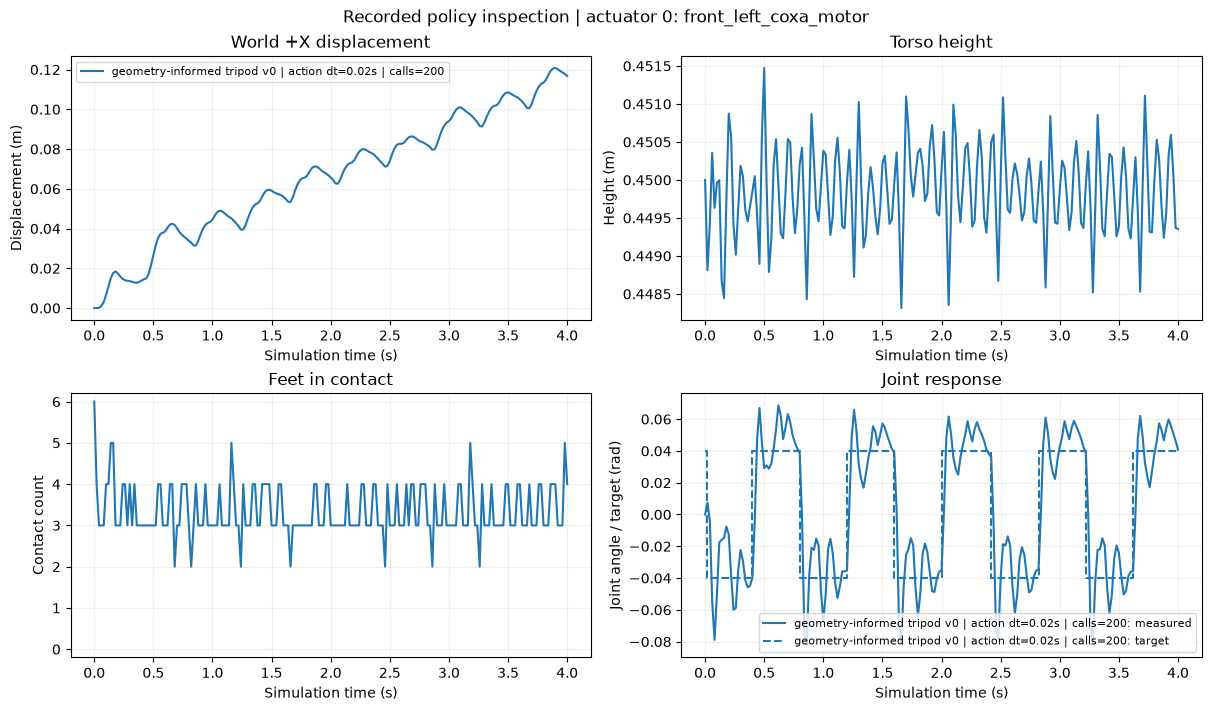

In [21]:
def geometry_gait(state):
    offsets = np.zeros(18)

    phase = 2 * np.pi * state.time / GAIT_PERIOD_S

    for leg_index, leg in enumerate(LEGS):
        # Opposite phase for alternating tripods.
        leg_phase = phase if leg in TRIPOD_A else phase + np.pi

        swing = np.sin(leg_phase) > 0

        info = geometry[leg]

        coxa_index = leg_index * 3
        hip_index = coxa_index + 1
        knee_index = coxa_index + 2

        # stance: push foot backward
        # swing: bring foot forward
        direction = -1 if swing else 1

        offsets[coxa_index] = (
            direction
            * info["backward_sign"]
            * COXA_SWEEP_RAD
        )

        # Lift only during swing.
        if swing:
            lift_index = hip_index if info["lift_joint"] == "hip" else knee_index
            offsets[lift_index] = info["lift_sign"] * LIFT_RAD

    return offsets


gait_recording = record_policy(
    geometry_gait,
    label="geometry-informed tripod v0",
    action_count=200,
    physics_steps=10,
)

plot_recordings(gait_recording)

In [22]:
# Viewer disabled during iteration. Uncomment to replay the saved shuffle.
# gait_recording.watch(
#     Path("telemetry/geometry-tripod-v0"),
#     speed=0.5,
# )


In [23]:
# Basic policy over gait parameters: measured state -> sweep/lift -> 18 joint offsets.
# The fixed geometry_gait above remains the control. No training or rollout runs here.
# Period stays fixed: changing time / period on every call would jump the gait phase.
TARGET_SPEED_M_S = 0.03  # Editable first target, not a demonstrated capability.


SPEED_GAIN = 0.5  # rad / (m/s); a starting hypothesis, not a tuned gain.
SWEEP_MIN_RAD, SWEEP_MAX_RAD = 0.0, 0.08


def gait_parameter_policy(state, target_speed_m_s=TARGET_SPEED_M_S):
    measured_speed = state.torso_velocity[0]
    speed_error = target_speed_m_s - measured_speed

    raw_sweep_rad = COXA_SWEEP_RAD + SPEED_GAIN * speed_error
    sweep_rad = np.clip(raw_sweep_rad, SWEEP_MIN_RAD, SWEEP_MAX_RAD)

    return float(sweep_rad), float(LIFT_RAD)


# Existing gait plumbing, copied with explicit parameters instead of mutable globals.
def gait_from_parameters(state, sweep_rad, lift_rad):
    offsets = np.zeros(18)

    phase = 2 * np.pi * state.time / GAIT_PERIOD_S

    for leg_index, leg in enumerate(LEGS):
        # Opposite phase for alternating tripods.
        leg_phase = phase if leg in TRIPOD_A else phase + np.pi

        swing = np.sin(leg_phase) > 0

        info = geometry[leg]

        coxa_index = leg_index * 3
        hip_index = coxa_index + 1
        knee_index = coxa_index + 2

        # stance: push foot backward
        # swing: bring foot forward
        direction = -1 if swing else 1

        offsets[coxa_index] = (
            direction
            * info["backward_sign"]
            * sweep_rad
        )

        # Lift only during swing.
        if swing:
            lift_index = hip_index if info["lift_joint"] == "hip" else knee_index
            offsets[lift_index] = info["lift_sign"] * lift_rad

    return offsets


def basic_gait_policy(state):
    sweep_rad, lift_rad = gait_parameter_policy(state)
    return gait_from_parameters(state, sweep_rad, lift_rad)


# Diagnostics use synthetic velocities on a recorded state. No physics runs.
from dataclasses import replace
probe_state = gait_recording.measurements[0]
policy_cases = [
    ("stopped", 0.0, 0.0),
    ("at forward target", TARGET_SPEED_M_S, 0.0),
    ("twice forward target", 2 * TARGET_SPEED_M_S, 0.0),
    ("sideways only", 0.0, TARGET_SPEED_M_S),
    ("fast forward", 0.5, 0.0),
    ("fast backward", -0.5, 0.0),
    ("fast sideways", 0.0, 0.5),
    ("fast sideways opposite", 0.0, -0.5),
]
policy_diagnostics = []

for name, vx, vy in policy_cases:  # ← diagnostic loop starts here
    probe = replace(
        probe_state,
        torso_velocity=(vx, vy, 0.0)
    )

    sweep, lift = gait_parameter_policy(probe)

    policy_diagnostics.append(dict(
        case=name,
        forward_m_s=vx,
        sideways_m_s=vy,
        target_m_s=TARGET_SPEED_M_S,
        sweep_rad=sweep,
        change_from_baseline_rad=sweep - COXA_SWEEP_RAD,
        lift_rad=lift,
        within_bounds=SWEEP_MIN_RAD <= sweep <= SWEEP_MAX_RAD,
    ))


In [24]:
for state in iteration_control.measurements:
    sweep, lift = gait_parameter_policy(state)

    if not SWEEP_MIN_RAD <= sweep <= SWEEP_MAX_RAD:
        print("first invalid state")
        print("time:", state.time)
        print("forward velocity:", state.torso_velocity[0])
        print("speed error:", TARGET_SPEED_M_S - state.torso_velocity[0])
        print("sweep:", sweep)
        print("lift:", lift)
        break

NameError: name 'iteration_control' is not defined

,treatment,seconds,forward_m,mean_forward_m_s,sideways_m,minimum_height_m
0,fixed control,5.0,0.140608,0.028122,0.003545,0.448313
1,your policy,5.0,-0.037958,-0.007592,0.150726,0.442613


,time,forward_m_s,target_m_s,sweep_rad,lift_rad
0,0.00,0.000000,0.03,0.055000,0.05
1,0.02,-0.003874,0.03,0.056937,0.05
2,0.04,0.021260,0.03,0.044370,0.05
3,0.06,0.092620,0.03,0.008690,0.05
4,0.08,0.171898,0.03,0.000000,0.05
5,0.10,0.207967,0.03,0.000000,0.05
6,0.12,0.169014,0.03,0.000000,0.05
7,0.14,0.058484,0.03,0.025758,0.05
8,0.16,-0.062994,0.03,0.080000,0.05
9,0.18,-0.088193,0.03,0.080000,0.05


Viewer opened (PID 48512). Recorded states: c:\Users\haidm\Desktop\robotics\spider\telemetry\gait-policy-iterations\treatment-cp863h3r
Viewer opened (PID 45316). Recorded states: c:\Users\haidm\Desktop\robotics\spider\telemetry\gait-policy-iterations\treatment-09ndxul6


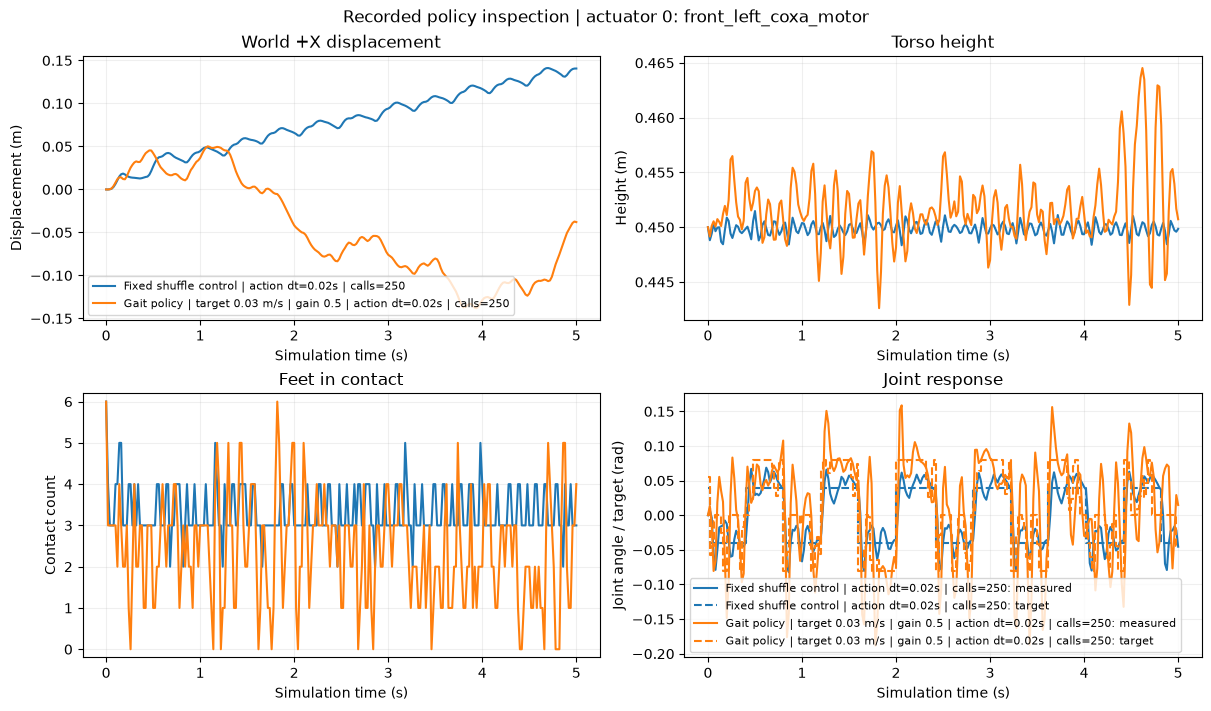

In [25]:
# CHANGE -> OBSERVE. Run this cell explicitly after editing/running the policy cell.
# Executes two fresh 5-second rollouts, prints diagnostics, and opens both replays.
# No gradients or weight updates. Existing baseline recordings remain untouched.
iteration_action_count = 250
iteration_physics_steps = 10
iteration_log = []


def inspected_gait_policy(state):
    sweep, lift = gait_parameter_policy(state)
    # Reject invalid knobs instead of silently correcting the policy under study.
    if not np.isfinite([sweep, lift]).all() or not SWEEP_MIN_RAD <= sweep <= SWEEP_MAX_RAD:
        raise ValueError(f"Invalid sweep/lift: {sweep}, {lift}. Inspect the diagnostic cases first.")
    iteration_log.append(dict(time=state.time, forward_m_s=state.torso_velocity[0],
                              target_m_s=TARGET_SPEED_M_S, sweep_rad=sweep, lift_rad=lift))
    return gait_from_parameters(state, sweep, lift)


iteration_control = record_policy(
    geometry_gait, label="Fixed shuffle control", action_count=iteration_action_count,
    physics_steps=iteration_physics_steps,
)
iteration_candidate = record_policy(
    inspected_gait_policy, label=f"Gait policy | target {TARGET_SPEED_M_S} m/s | gain {SPEED_GAIN}",
    action_count=iteration_action_count, physics_steps=iteration_physics_steps,
)
iteration_summary = []
for label, recorded in [("fixed control", iteration_control), ("your policy", iteration_candidate)]:
    times = np.asarray(recorded.replay.times)
    expected = np.arange(iteration_action_count + 1) * iteration_physics_steps * recorded.replay.model.opt.timestep
    if not np.allclose(times, expected, rtol=0, atol=1e-9) or not np.isfinite(recorded.replay.states).all():
        raise RuntimeError(f"{label}: invalid simulation. Do not compare its final displacement.")
    first, last = recorded.measurements[0], recorded.measurements[-1]
    duration = last.time - first.time
    dx = last.torso_position[0] - first.torso_position[0]
    iteration_summary.append(dict(
        treatment=label, seconds=duration, forward_m=dx,
        mean_forward_m_s=dx / duration,
        sideways_m=last.torso_position[1] - first.torso_position[1],
        minimum_height_m=min(state.torso_position[2] for state in recorded.measurements),
    ))
display(pd.DataFrame(iteration_summary))
display(pd.DataFrame(iteration_log).head(12))
plot_recordings(iteration_control, iteration_candidate)
# Exact recorded states. Close these windows before running another comparison.
iteration_viewers = [
    recorded.watch(REPO_ROOT / "telemetry" / "gait-policy-iterations", speed=1.0)
    for recorded in (iteration_control, iteration_candidate)
]
